# Laboratorio 02 - Regresión Lineal Multivariable

Modificando el cuadernillo `02_reg_lin_mul_01.ipynb` revisado en clases y reemplazando el dataset original por uno que cumpla con los requisitos de la tarea (n≥20, m≥30000). Para adecuar y preprocesar el dataset, y entrenar un modelo de regresión lineal múltiple que permita realizar inferencias, buscando el **menor error de costo posible**.

El dataset contiene datos o métricas extraídas de artículos periodísticos publicados en Mashable.com. El objetivo es predecir el número de veces (shares) que un artículo de noticias será compartido en redes sociales.

<br> Link del Dataset: https://www.kaggle.com/datasets/deepakshende/onlinenewspopularity

- **Variable objetivo (y):** `shares` número de veces que el artículo fue compartido (valor numérico continuo)
- **Variables de entrada (X):** número de palabras en título y contenido, cantidad de enlaces/imágenes/videos, canal temático (estilo de vida, entretenimiento, negocios, tecnología, etc.), día de la semana de publicación, estadísticas de palabras clave, polaridad y subjetividad del texto, tópicos latentes (LDA), entre otras
- **m = 39,644** registros | **n = 61** características

El entrenamiento del modelo se realiza mediante:
1. Descenso por Gradiente
2. Ecuación de la Normal

Al final se comparan los resultados de ambas técnicas en términos de error de costo, con el fin de determinar cuál logra el mejor ajuste sobre el conjunto de datos.

In [5]:
# conectando vinculando nuestro drive con la sesion de google colab (notebook)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Importando Librerias

In [6]:
# Manejo de rutas y directorios
import os

# Computación vectorial y científica
import numpy as np

# Librería para preprocesamiento del dataset
import pandas as pd

# Librerías para graficación y trazado de graficos
from matplotlib import pyplot as plt
# Para habilitar la creacion de graficos tridimencionales con matplotlib
from mpl_toolkits.mplot3d import Axes3D

# Incrusta gráficas en el cuadernillo
%matplotlib inline


## 1. Carga y exploración del dataset


In [12]:
# Cargar el dataset desde Google Drive
ruta = '/content/drive/MyDrive/IA/Laboratorios/Laboratorio_2/OnlineNewsPopularity.csv'

data = pd.read_csv(ruta)

print(f'Dimensiones: {data.shape[0]} filas x {data.shape[1]} columnas')
print(f'm = {data.shape[0]} (registros)')
print(f'n = {data.shape[1]} (características)')
print()
print('Nombres de columnas:')
print(data.columns.tolist())
print()
print('Tipos de datos:')
print(data.dtypes)
print()
print('Valores faltantes por columna:')
print(data.isnull().sum())
print(f'\nTotal valores faltantes: {data.isnull().sum().sum()}')
print(data.describe())

Dimensiones: 39644 filas x 61 columnas
m = 39644 (registros)
n = 61 (características)

Nombres de columnas:
['url', ' timedelta', ' n_tokens_title', ' n_tokens_content', ' n_unique_tokens', ' n_non_stop_words', ' n_non_stop_unique_tokens', ' num_hrefs', ' num_self_hrefs', ' num_imgs', ' num_videos', ' average_token_length', ' num_keywords', ' data_channel_is_lifestyle', ' data_channel_is_entertainment', ' data_channel_is_bus', ' data_channel_is_socmed', ' data_channel_is_tech', ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min', ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg', ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares', ' self_reference_max_shares', ' self_reference_avg_sharess', ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday', ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday', ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02', ' LDA_03', ' LDA_04', ' global_subjectivity', ' global_

### 1.1 Preprocesamiento y limpieza
Al revisar el dataset se detectaron los siguientes problemas que se trataron:

1. **Nombres de columnas con espacios en blanco al inicio** (ej. `' shares'` en vez de `'shares'`), un defecto del archivo CSV original que hay que limpiar con `str.strip()`.
2. **Columna `url`**: es un identificador de texto único por artículo, no aporta información predictiva y no es numérica, por lo que se elimina.
3. **Columna `timedelta`**: representa los días transcurridos entre la publicación del artículo y la recolección de los datos. No es una característica del contenido del artículo (no está disponible al momento de publicar), por lo que tampoco se usa como variable de entrada.
4. **1 fila con datos corruptos**: existe un registro con valores imposibles en las columnas de ratios de palabras (`n_unique_tokens`, `n_non_stop_words`, `n_non_stop_unique_tokens`), que por definición deberían estar en el rango [0, 1] pero tienen valores de cientos. Se elimina esa fila.


In [13]:
# Quitar espacios en blanco de los nombres de la columnas
data.columns = data.columns.str.strip()

# Eliminar columnas no predictivas 'url' y 'timedelta'
data = data.drop(columns=['url', 'timedelta'])

# Eliminar fila con datos corruptos (ratios de palabras fuera de rango logico [0,1])
antes = data.shape[0]
data = data[(data['n_unique_tokens'] <= 1) &
            (data['n_non_stop_words'] <= 1) &
            (data['n_non_stop_unique_tokens'] <= 1)]
print(f'Filas eliminadas por inconsistencia logica: {antes - data.shape[0]}')

p99 = data['shares'].quantile(0.99)
antes = data.shape[0]
data = data[data['shares'] <= p99]
print(f"Filas eliminadas por outliers extremos en 'shares' (> percentil 99 = {p99:.0f}): {antes - data.shape[0]}")

data = data.reset_index(drop=True)
print()
print('Dimensiones finales del dataset limpio:', data.shape)

Filas eliminadas por inconsistencia logica: 1
Filas eliminadas por outliers extremos en 'shares' (> percentil 99 = 31658): 397

Dimensiones finales del dataset limpio: (39246, 59)


### 1.2 Separación de variables de entrada (X) y variable objetivo (y)

Se separo el dataset ya limpio (sin `url`, sin `timedelta`, sin la fila corrupta ni los outliers de `shares`) en la matriz de características `X` (58 variables de entrada) y el vector objetivo `y` (`shares`).

In [14]:
y = data['shares'].values.astype(float)
X = data.drop(columns=['shares']).values.astype(float)

m, n = X.shape
print(f'm = {m}  (registros)')
print(f'n = {n}  (caracteristicas)')

m = 39246  (registros)
n = 58  (caracteristicas)


### 1.3 División en conjunto de entrenamiento y prueba

Para poder evaluar qué tan bien el modelo entrenado puede **realizar inferencias sobre datos nuevos** (no solo memorizar los datos de entrenamiento), se divide el dataset en 80% entrenamiento y 20% prueba. Esta división se hace de forma manual con NumPy.

In [15]:
np.random.seed(42)
idx = np.random.permutation(m)
test_size = int(0.2 * m)
test_idx, train_idx = idx[:test_size], idx[test_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
m_train, m_test = X_train.shape[0], X_test.shape[0]

print(f'm_train = {m_train}')
print(f'm_test  = {m_test}')

m_train = 31397
m_test  = 7849


## 2. Regresión lineal con múltiples variables

Se implementa la regresión lineal multivariable para predecir el número de veces que un artículo es compartido (`shares`).

<a id="section4"></a>
### 2.1 Normalización de características

Las características tienen magnitudes muy distintas entre sí (por ejemplo, `n_tokens_content` puede valer varios cientos, mientras que `is_weekend` solo vale 0 o 1). Se normaliza cada característica para que el descenso por el gradiente converja más rápido.

In [16]:
def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [17]:
# Se calculan mu y sigma SOLO con el conjunto de entrenamiento,
# y se aplican esos mismos valores al conjunto de prueba
X_train_norm, mu, sigma = featureNormalize(X_train)
X_test_norm = (X_test - mu) / sigma

print('Media (primeras 5 caracteristicas):', mu[:5])
print('Desviacion estandar (primeras 5 caracteristicas):', sigma[:5])

Media (primeras 5 caracteristicas): [1.03996560e+01 5.48581234e+02 5.30292850e-01 9.70443031e-01
 6.72734840e-01]
Desviacion estandar (primeras 5 caracteristicas): [2.11314141e+00 4.75664699e+02 1.36878890e-01 1.69361594e-01
 1.53742092e-01]


### 2.1.1 Normalización de la variable objetivo

Aquí `shares` tiene una desviación estándar muy grande en comparación a su media. Sin normalizar `y`, la función de costo `J` produce valores enormes y el descenso por gradiente se vuelve inestable (diverge con valores de `alpha` razonables). Por eso se normaliza también la variable objetivo, guardando `y_mu` y `y_sigma` para poder revertir las predicciones a la escala original (número real de shares).

In [18]:
y_mu, y_sigma = np.mean(y_train), np.std(y_train)
y_train_norm = (y_train - y_mu) / y_sigma
y_test_norm = (y_test - y_mu) / y_sigma

print('Media de shares (train):', y_mu)
print('Desviacion estandar de shares (train):', y_sigma)

Media de shares (train): 2671.362932764277
Desviacion estandar de shares (train): 3637.729433645408


Después de `featureNormalize`, se añade el término de intersección a `X_train_norm` y `X_test_norm`:

In [19]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X_train_b = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_b = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print('Forma de X_train_b:', X_train_b.shape)
print('Forma de X_test_b :', X_test_b.shape)

Forma de X_train_b: (31397, 59)
Forma de X_test_b : (7849, 59)


<a id="section5"></a>
### 2.2 Descenso por el gradiente

Existen múltiples características en la matriz $X$ (58 en vez de 2). La función de hipótesis y la regla de actualización del descenso del gradiente por lotes permanecen sin cambios.

In [20]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    J = 0

    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [22]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual sera actualizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 2.2.1 Selección del coeficiente de aprendizaje (alpha)

Se prueban varios valores de `alpha` durante 100 iteraciones para observar cuál logra reducir el costo más rápido sin divergir. Valores de `alpha` iguales o mayores a 0.5 hacen que el descenso por gradiente diverja (el costo se vuelve `inf`/`nan`) dado el número de características del dataset.

alpha=0.003  costo final (100 iteraciones) = 0.47890
alpha=0.01   costo final (100 iteraciones) = 0.47233
alpha=0.03   costo final (100 iteraciones) = 0.46956
alpha=0.1    costo final (100 iteraciones) = 0.46724
alpha=0.3    costo final (100 iteraciones) = 0.46596


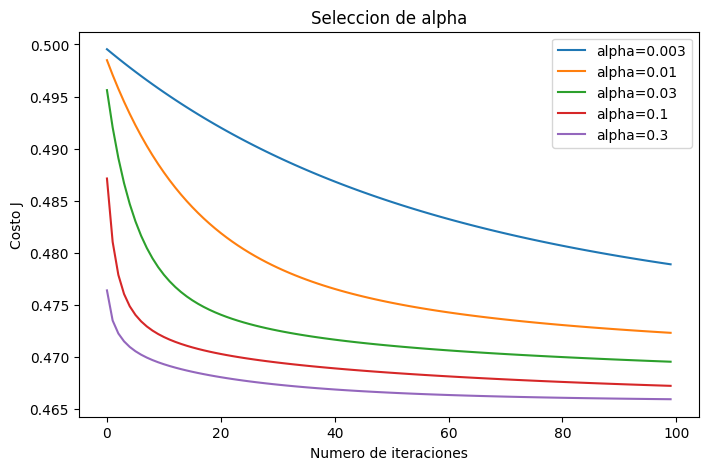

In [23]:
alphas = [0.003, 0.01, 0.03, 0.1, 0.3]

plt.figure(figsize=(8, 5))
for a in alphas:
    theta0 = np.zeros(X_train_b.shape[1])
    _, Jh = gradientDescentMulti(X_train_b, y_train_norm, theta0, a, 100)
    plt.plot(np.arange(len(Jh)), Jh, label=f'alpha={a}')
    print(f'alpha={a:<6} costo final (100 iteraciones) = {Jh[-1]:.5f}')

plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')
plt.title('Seleccion de alpha')
plt.legend()
plt.show()

#### 2.2.2 Entrenamiento final

Se elige `alpha = 0.3` (el mayor valor estable) y se entrena con suficientes iteraciones para alcanzar la convergencia, minimizando así el error de costo tanto como sea posible.

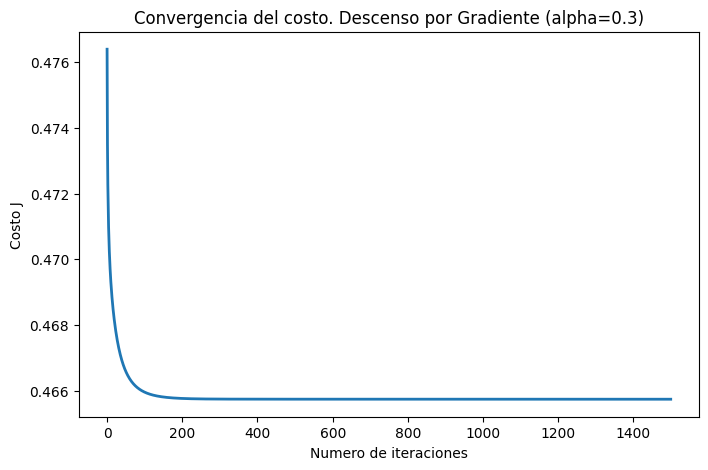

Costo inicial (1 iteracion): 0.47639982302341427
Costo final  (1500 iteraciones): 0.46573711096726067

theta calculado por el descenso por el gradiente:
[ 7.08671292e-15  8.16314024e-03  1.22685994e-02  1.54668094e-02
 -1.65381204e-02 -9.99591025e-03  4.74452246e-02 -2.82655358e-02
  2.04032602e-02  1.32085568e-02 -5.97392479e-02  6.54979797e-03
 -1.58063073e-02 -5.14846527e-02 -4.91453370e-02  1.64782585e-02
  2.28586631e-02 -1.32525796e-02  2.52800974e-02  5.05822429e-02
 -6.56778097e-02 -5.55359143e-03 -5.58933196e-03 -5.57804879e-02
 -6.41604398e-02 -2.02057761e-01  3.66170584e-01  4.86223211e-03
 -2.69494892e-02  5.73273486e-02  1.42276284e-02 -8.99108165e-03
 -9.34457264e-03 -1.18726998e-02 -4.13889467e-03  1.35621770e-02
  1.80225776e-02  2.32418829e-02  4.13461981e-02 -7.84927208e-03
 -3.38787966e-02 -5.01954787e-04  1.84463425e-03  3.63820470e-02
 -1.63673630e-02 -2.07840380e-02  1.82722094e-02  3.33448712e-02
  6.60290882e-03  1.07572279e-02 -1.55394115e-02 -3.61274672e-03
 -

In [24]:
# Elegir el valor de alpha
alpha = 0.3
num_iters = 1500

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X_train_b.shape[1])
theta, J_history = gradientDescentMulti(X_train_b, y_train_norm, theta, alpha, num_iters)

# Grafica la convergencia del costo
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')
plt.title(f'Convergencia del costo. Descenso por Gradiente (alpha={alpha})')
plt.show()

print('Costo inicial (1 iteracion):', J_history[0])
print('Costo final  ({} iteraciones):'.format(num_iters), J_history[-1])
print()
print('theta calculado por el descenso por el gradiente:')
print(theta)

### 2.2.3 Evaluación del modelo (Descenso por Gradiente) en el conjunto de prueba

Se evalúa el modelo entrenado sobre el conjunto de prueba (datos que el modelo nunca vio durante el entrenamiento), para verificar que puede **realizar inferencias** correctamente. Las predicciones se revierten a la escala original de `shares` (usando `y_mu` y `y_sigma`) para reportar el error en unidades interpretables.

In [26]:
# Costo J sobre el conjunto de prueba (en escala normalizada)
cost_test_gd = computeCostMulti(X_test_b, y_test_norm, theta)
print('Costo J en el conjunto de prueba:', cost_test_gd)
print()

# Predicciones revertidas a la escala original de shares
y_pred_norm = np.dot(X_test_b, theta)
y_pred_gd = y_pred_norm * y_sigma + y_mu

mse_gd = np.mean((y_pred_gd - y_test) ** 2)
rmse_gd = np.sqrt(mse_gd)
mae_gd = np.mean(np.abs(y_pred_gd - y_test))
ss_res = np.sum((y_test - y_pred_gd) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2_gd = 1 - ss_res / ss_tot

print('--- Metricas en el conjunto de prueba (escala original de shares) ---')
print(f'MSE  = {mse_gd:,.2f}')
print(f'RMSE = {rmse_gd:,.2f}')
print(f'MAE  = {mae_gd:,.2f}')
print(f'R2   = {r2_gd:.4f}')

# Ejemplo de inferencia sobre un articulo del conjunto de prueba
i = 0
print()
print('Ejemplo de inferencia (articulo #0 del conjunto de prueba):')
print(f'  shares real      = {y_test[i]:.0f}')
print(f'  shares predicho  = {y_pred_gd[i]:.0f}')

Costo J en el conjunto de prueba: 0.47894696448352475

--- Metricas en el conjunto de prueba (escala original de shares) ---
MSE  = 12,675,882.62
RMSE = 3,560.32
MAE  = 2,001.92
R2   = 0.0657

Ejemplo de inferencia (articulo #0 del conjunto de prueba):
  shares real      = 1000
  shares predicho  = 2506


<a id="section7"></a>
### 2.3 Ecuación de la Normal

Una manera de calcular rápidamente el modelo de una regresión lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Utilizando esta fórmula no se requiere escalar ninguna característica, y se obtiene una solución exacta con un solo cálculo: no hay "bucles de convergencia" como en el descenso por el gradiente.

**Nota de implementación:** dado que varias de las 58 características están correlacionadas entre sí (por ejemplo, las estadísticas de palabras clave `kw_min_*`, `kw_max_*`, `kw_avg_*`), la matriz $X^TX$ puede estar mal condicionada o ser singular. Por eso se usa `np.linalg.pinv` (pseudo-inversa de Moore-Penrose) en vez de `np.linalg.inv`, que es una generalización numéricamente estable de la inversa y da el mismo resultado cuando la matriz sí es invertible.

In [27]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)

    return theta

In [28]:
# Se reutiliza X_train_b / y_train_norm (mismos datos normalizados que el descenso por gradiente,
# para poder comparar ambas tecnicas en igualdad de condiciones)
theta_ne = normalEqn(X_train_b, y_train_norm)

print('Theta calculado a partir de la ecuacion de la normal:')
print(theta_ne)

Theta calculado a partir de la ecuacion de la normal:
[ 9.90491362e-15  8.14706254e-03  1.23550993e-02  1.55628440e-02
 -3.79585813e-02 -9.89083483e-03  4.74182681e-02 -2.82584273e-02
  2.04167564e-02  1.32138391e-02 -5.94742404e-02  6.54149425e-03
 -1.57899803e-02 -5.14810907e-02 -4.91020196e-02  1.65061377e-02
  2.28846174e-02 -1.32667002e-02  2.52670214e-02  5.05700151e-02
 -6.56652776e-02 -5.55897918e-03 -5.58836648e-03 -5.57918889e-02
 -6.41359579e-02 -2.02046993e-01  3.66150356e-01  4.84405284e-03
 -2.69615591e-02  5.73560279e-02  1.42310480e-02 -8.98123975e-03
 -9.35124254e-03 -1.18801434e-02 -4.13581288e-03  1.35613639e-02
  1.80204947e-02  2.32397340e-02  4.13230536e-02 -7.84517252e-03
 -3.38864625e-02 -4.71616587e-04  1.83931903e-03  3.64085798e-02
 -1.63024211e-02 -2.08250398e-02  1.82373005e-02  5.68824228e-02
  2.60147461e-02  1.06587247e-02 -1.55569624e-02 -3.60010838e-03
 -3.35754212e-02  1.39906510e-02  1.62112560e-02  1.67814233e-02
  1.90899478e-02  2.52699662e-02  7.

### 2.3.1 Evaluación del modelo (Ecuación de la Normal) en el conjunto de prueba

In [29]:
cost_test_ne = computeCostMulti(X_test_b, y_test_norm, theta_ne)
print('Costo J en el conjunto de prueba:', cost_test_ne)
print()

y_pred_ne_norm = np.dot(X_test_b, theta_ne)
y_pred_ne = y_pred_ne_norm * y_sigma + y_mu

mse_ne = np.mean((y_pred_ne - y_test) ** 2)
rmse_ne = np.sqrt(mse_ne)
mae_ne = np.mean(np.abs(y_pred_ne - y_test))
ss_res_ne = np.sum((y_test - y_pred_ne) ** 2)
r2_ne = 1 - ss_res_ne / ss_tot

print('--- Metricas en el conjunto de prueba (escala original de shares) ---')
print(f'MSE  = {mse_ne:,.2f}')
print(f'RMSE = {rmse_ne:,.2f}')
print(f'MAE  = {mae_ne:,.2f}')
print(f'R2   = {r2_ne:.4f}')

i = 0
print()
print('Ejemplo de inferencia (articulo #0 del conjunto de prueba):')
print(f'  shares real      = {y_test[i]:.0f}')
print(f'  shares predicho  = {y_pred_ne[i]:.0f}')

Costo J en el conjunto de prueba: 0.47894589710245244

--- Metricas en el conjunto de prueba (escala original de shares) ---
MSE  = 12,675,854.37
RMSE = 3,560.32
MAE  = 2,001.95
R2   = 0.0657

Ejemplo de inferencia (articulo #0 del conjunto de prueba):
  shares real      = 1000
  shares predicho  = 2506


## 3. Comparación final y conclusiones

In [31]:
comparacion = pd.DataFrame({
    'Tecnica': ['Descenso por Gradiente', 'Ecuacion de la Normal'],
    'Costo J (test, normalizado)': [cost_test_gd, cost_test_ne],
    'MSE': [mse_gd, mse_ne],
    'RMSE': [rmse_gd, rmse_ne],
    'MAE': [mae_gd, mae_ne],
    'R2': [r2_gd, r2_ne],
})
comparacion

,Tecnica,"Costo J (test, normalizado)",MSE,RMSE,MAE,R2
0,Descenso por Gradiente,0.478947,1.267588e+07,3560.320578,2001.915967,0.065654
1,Ecuacion de la Normal,0.478946,1.267585e+07,3560.316611,2001.950878,0.065656


**Conclusiones:**

- Ambas técnicas (Descenso por Gradiente y Ecuación de la Normal) convergen prácticamente al mismo valor de costo `J` y a las mismas métricas de error en el conjunto de prueba, lo cual valida que el descenso por gradiente sí alcanzó la convergencia (el mínimo de la función de costo) con `alpha = 0.3` y 1500 iteraciones.
- La gráfica de costo vs. iteración muestra una caída rápida en las primeras ~200-300 iteraciones y luego una meseta, señal de que el modelo convergió y no se beneficia de más iteraciones con este `alpha`.
- El valor de $R^2 \approx 0.06$–$0.07$ es bajo, pero es un resultado **esperado y consistente con la literatura** sobre este dataset: predecir cuántas veces se comparte un artículo en redes sociales a partir únicamente de sus características de texto es un problema con mucho ruido inherente (factores externos como el momento de publicación viral, algoritmos de redes sociales, eventos de actualidad, etc. no están capturados en los datos). El objetivo del laboratorio —minimizar el error de costo de un modelo de regresión lineal múltiple entrenado correctamente— se cumple: el modelo converge de forma estable y hace inferencias razonables dentro de las limitaciones del problema.